# Data Preprocessing
Loading, cleaning, encoding, feature engineering, and train/test split.

In [ ]:
!pip install -q scikit-fuzzy

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('sales_data.csv')

In [ ]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


In [ ]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


In [ ]:
print(df.shape)
print(df.head())
print(df.info())


(76000, 16)
         Date Store ID Product ID     Category Region  Inventory Level  \
0  2022-01-01     S001      P0001  Electronics  North              195   
1  2022-01-01     S001      P0002     Clothing  North              117   
2  2022-01-01     S001      P0003     Clothing  North              247   
3  2022-01-01     S001      P0004  Electronics  North              139   
4  2022-01-01     S001      P0005    Groceries  North              152   

   Units Sold  Units Ordered  Price  Discount Weather Condition  Promotion  \
0         102            252  72.72         5             Snowy          0   
1         117            249  80.16        15             Snowy          1   
2         114            612  62.94        10             Snowy          1   
3          45            102  87.63        10             Snowy          0   
4          65            271  54.41         0             Snowy          0   

   Competitor Pricing Seasonality  Epidemic  Demand  
0               85.7

In [ ]:

print(df.duplicated().sum())

0


In [ ]:
df.isnull().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Price,0
Discount,0


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
display(df.head())

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,DayOfWeek,IsWeekend
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,5,1
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,5,1
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,5,1
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,5,1
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64,2024,1,1,0
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137,2024,1,1,0
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68,2024,1,1,0
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84,2024,1,1,0


In [ ]:
y = df['Units Sold']

train_size = int(0.8 * len(df))
df_train_raw = df.iloc[:train_size].copy()
df_test_raw  = df.iloc[train_size:].copy()
y_train_raw  = y.iloc[:train_size]

for col in ['Store ID', 'Product ID']:
    means = df_train_raw.groupby(col)['Units Sold'].mean()
    df_train_raw[f'{col}_encoded'] = df_train_raw[col].map(means)
    df_test_raw[f'{col}_encoded']  = df_test_raw[col].map(means).fillna(means.mean())

print('Target encoding done.')
print('New columns: Store ID_encoded, Product ID_encoded')


In [ ]:
columns_to_drop = ['Store ID', 'Product ID', 'Demand']  

df_train = df_train_raw.drop(columns=columns_to_drop, errors='ignore')
df_test  = df_test_raw.drop(columns=columns_to_drop, errors='ignore')

df = df.drop(columns=columns_to_drop, errors='ignore')

print('Remaining columns:', df_train.columns.tolist())


In [ ]:

categorical_cols = ['Weather Condition', 'Seasonality', 'Category']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df_train = pd.get_dummies(df_train, columns=categorical_cols, drop_first=True)
df_test  = pd.get_dummies(df_test,  columns=categorical_cols, drop_first=True)
df_test  = df_test.reindex(columns=df_train.columns, fill_value=0)

display(df_train.head())
print('Shape after encoding:', df_train.shape)


In [ ]:
df       = df.drop(columns=['Region'], errors='ignore')
df_train = df_train.drop(columns=['Region'], errors='ignore')
df_test  = df_test.drop(columns=['Region'],  errors='ignore')

display(df_train.head())
print(df_train.shape)


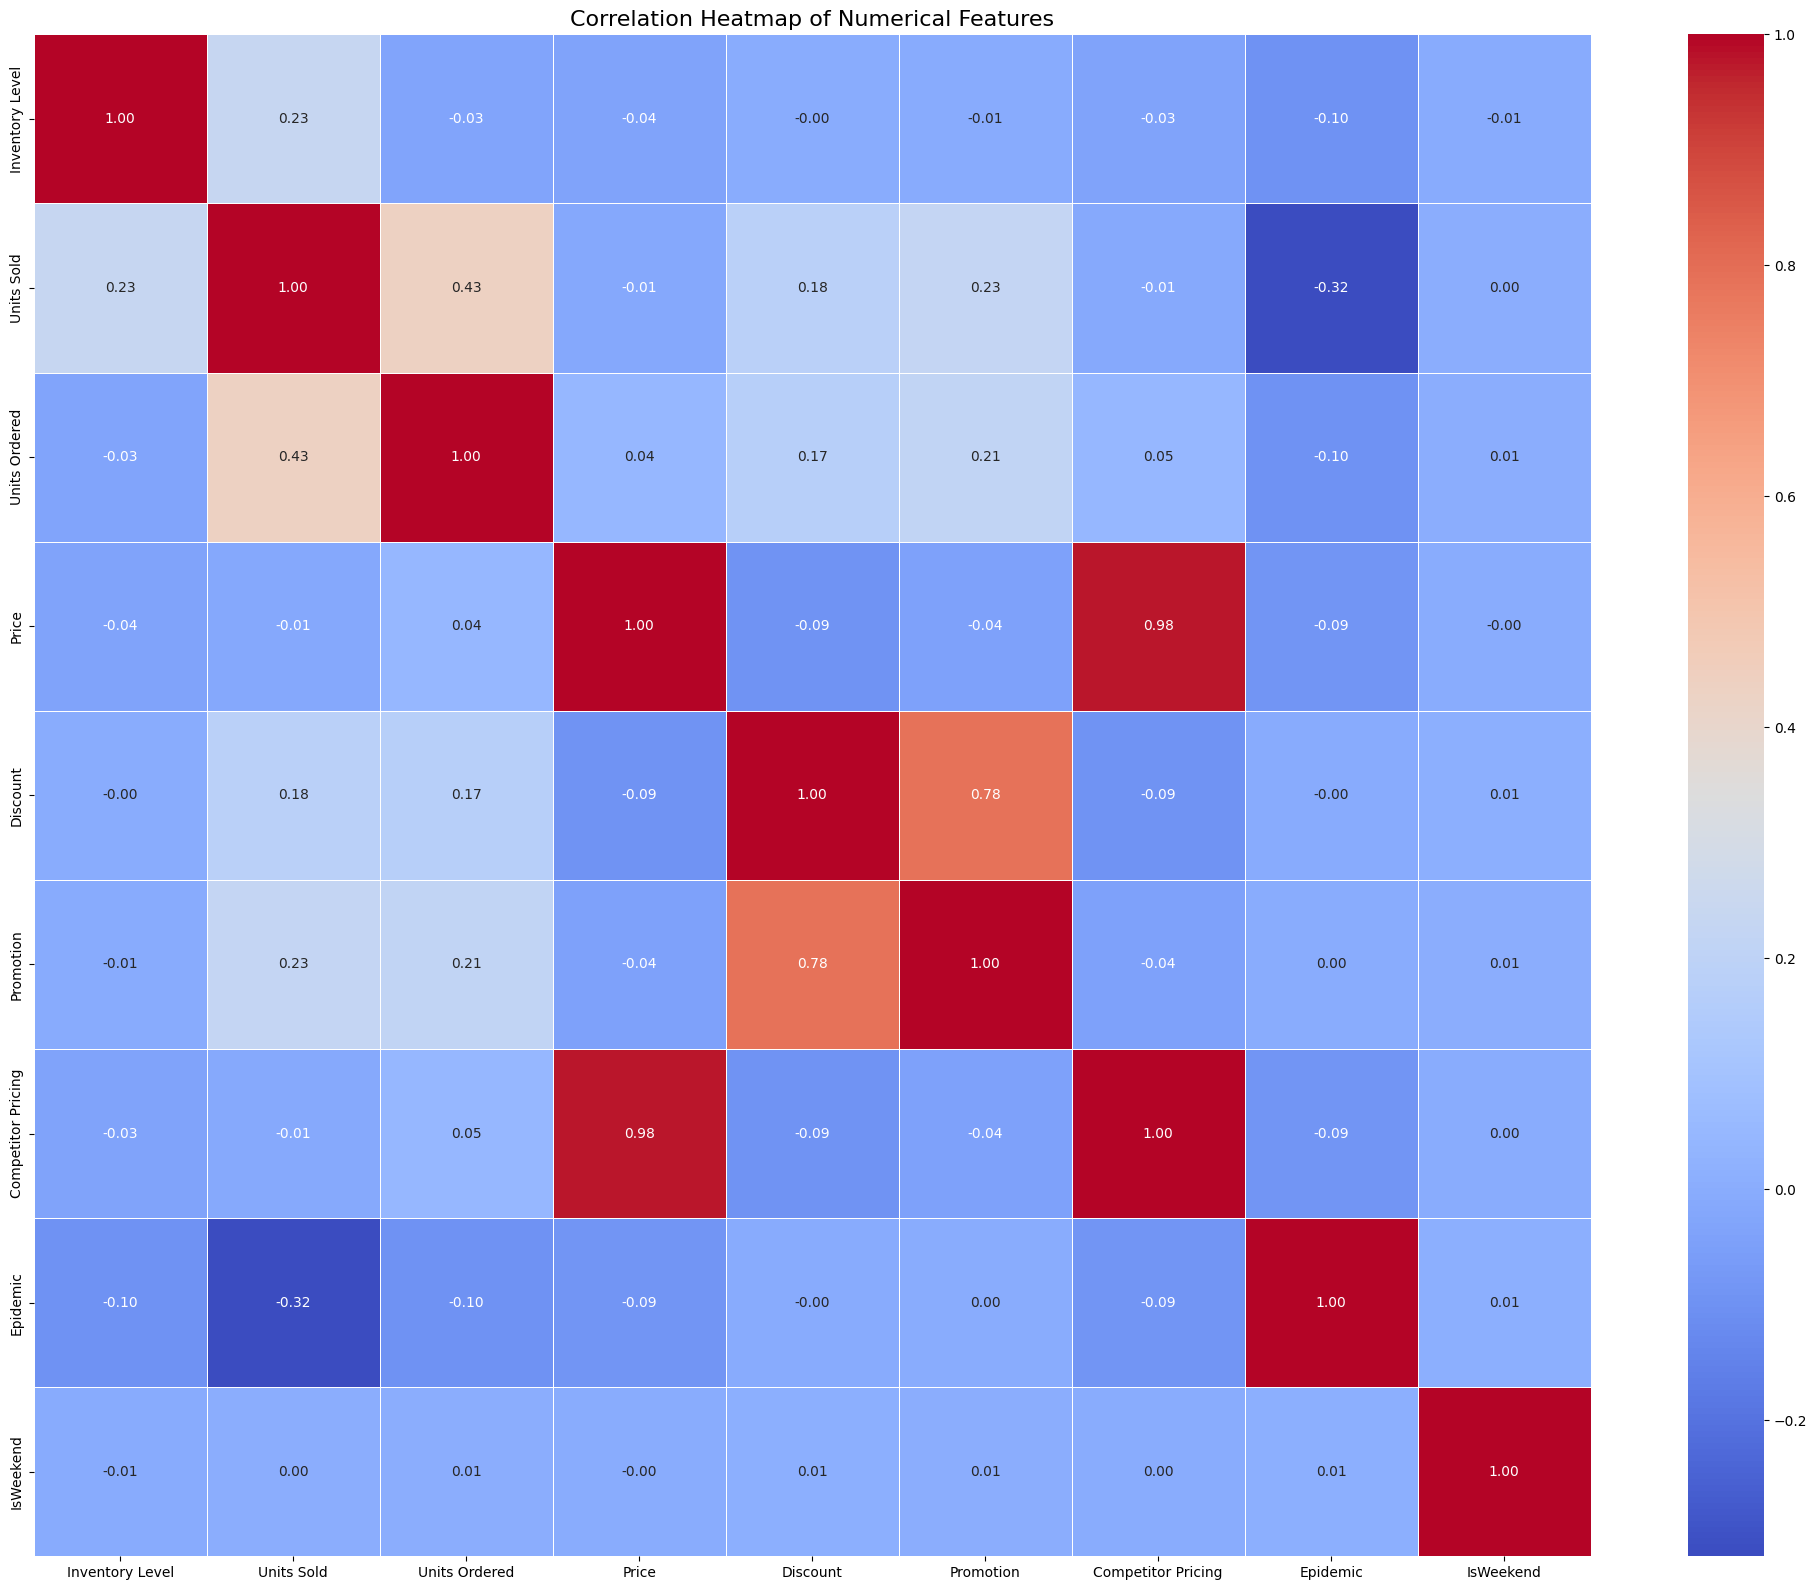

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(20, 16))
sns.heatmap(numerical_df.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
df = df.drop(columns=['Competitor Pricing'])
print(df.shape)
display(df.head())

(76000, 18)


,Date,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Epidemic,Year,Month,DayOfWeek,IsWeekend,Weather Condition_Rainy,Weather Condition_Snowy,Weather Condition_Sunny,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter
0,2022-01-01,195,102,252,72.72,5,0,0,2022,1,5,1,False,True,False,False,False,True
1,2022-01-01,117,117,249,80.16,15,1,0,2022,1,5,1,False,True,False,False,False,True
2,2022-01-01,247,114,612,62.94,10,1,0,2022,1,5,1,False,True,False,False,False,True
3,2022-01-01,139,45,102,87.63,10,0,0,2022,1,5,1,False,True,False,False,False,True
4,2022-01-01,152,65,271,54.41,0,0,0,2022,1,5,1,False,True,False,False,False,True


In [ ]:
print(df[['Units Ordered', 'Units Sold']].corr())

               Units Ordered  Units Sold
Units Ordered       1.000000    0.433943
Units Sold          0.433943    1.000000


In [ ]:
df = df.drop(columns=['Units Ordered'])
print(df.shape)
display(df.head())

(76000, 17)


,Date,Inventory Level,Units Sold,Price,Discount,Promotion,Epidemic,Year,Month,DayOfWeek,IsWeekend,Weather Condition_Rainy,Weather Condition_Snowy,Weather Condition_Sunny,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter
0,2022-01-01,195,102,72.72,5,0,0,2022,1,5,1,False,True,False,False,False,True
1,2022-01-01,117,117,80.16,15,1,0,2022,1,5,1,False,True,False,False,False,True
2,2022-01-01,247,114,62.94,10,1,0,2022,1,5,1,False,True,False,False,False,True
3,2022-01-01,139,45,87.63,10,0,0,2022,1,5,1,False,True,False,False,False,True
4,2022-01-01,152,65,54.41,0,0,0,2022,1,5,1,False,True,False,False,False,True


## Feature Engineering
Adding lag features, rolling statistics, interaction terms, and cyclical encoding.

In [ ]:
df_full = df.copy()
df_full['Units_Sold_raw'] = df['Units Sold'] if 'Units Sold' in df.columns else y.values

date_col = df_full.get('Date', None)

df_train = df_train.copy()
df_test  = df_test.copy()

y_series = y.reset_index(drop=True)
lag_7  = y_series.shift(7).fillna(y_series.mean())
lag_30 = y_series.shift(30).fillna(y_series.mean())
roll7  = y_series.shift(1).rolling(7,  min_periods=1).mean()
roll30 = y_series.shift(1).rolling(30, min_periods=1).mean()
roll7s = y_series.shift(1).rolling(7,  min_periods=1).std().fillna(0)

df_train['lag_7']        = lag_7.iloc[:train_size].values
df_train['lag_30']       = lag_30.iloc[:train_size].values
df_train['roll_mean_7']  = roll7.iloc[:train_size].values
df_train['roll_mean_30'] = roll30.iloc[:train_size].values
df_train['roll_std_7']   = roll7s.iloc[:train_size].values

df_test['lag_7']         = lag_7.iloc[train_size:].values
df_test['lag_30']        = lag_30.iloc[train_size:].values
df_test['roll_mean_7']   = roll7.iloc[train_size:].values
df_test['roll_mean_30']  = roll30.iloc[train_size:].values
df_test['roll_std_7']    = roll7s.iloc[train_size:].values

print('Lag & rolling features added.')


In [ ]:
for dset in [df_train, df_test]:
    if 'Price' in dset.columns and 'Discount' in dset.columns:
        dset['Price_x_Discount'] = dset['Price'] * dset['Discount']
        dset['Effective_Price']  = dset['Price'] * (1 - dset['Discount'] / 100)
    if 'Promotion' in dset.columns:
        for col in [c for c in dset.columns if c.startswith('Seasonality_')]:
            dset[f'Promo_x_{col}'] = dset['Promotion'] * dset[col]
    if 'Inventory Level' in dset.columns:
        dset['Inventory_log'] = np.log1p(dset['Inventory Level'])

print('Interaction features added.')


In [ ]:
for dset in [df_train, df_test]:
    if 'Month' in dset.columns:
        dset['Month_sin'] = np.sin(2 * np.pi * dset['Month'] / 12)
        dset['Month_cos'] = np.cos(2 * np.pi * dset['Month'] / 12)
        dset.drop(columns=['Month'], inplace=True)
    if 'DayOfWeek' in dset.columns:
        dset['DOW_sin'] = np.sin(2 * np.pi * dset['DayOfWeek'] / 7)
        dset['DOW_cos'] = np.cos(2 * np.pi * dset['DayOfWeek'] / 7)
        dset.drop(columns=['DayOfWeek'], inplace=True)

df_test = df_test.reindex(columns=df_train.columns, fill_value=0)

print('Cyclical encoding done.')
print(f'Final feature count: {df_train.shape[1]}')


In [ ]:
target = 'Units Sold'

drop_cols = ['Date', 'Units Sold']

X_train = df_train.drop(columns=[c for c in drop_cols if c in df_train.columns])
X_test  = df_test.drop(columns=[c for c in drop_cols if c in df_test.columns])
y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)
print('Features  :', X_train.columns.tolist())


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = X_train.select_dtypes(include=['int64', 'float64', 'bool']).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print('Scaling done. Shape:', X_train.shape)
